# Reto 2 · Modelo de la primera visita: ¿quién seguirá con la difusión alterada al año?

**Notebook 08.** Reenfoque del modelo predictivo. Los modelos anteriores (notebooks 06 y 07) intentaban predecir el fenotipo funcional a 3 meses **con los datos del alta**, y se quedaban en un AUC ≈ 0,63 con cualquier algoritmo. Pero el fenotipo del notebook 04 se define con la espirometría de los 3 meses, y esa visita existe en las tres cohortes. Aquí la pregunta cambia de momento: **en la consulta de los 3 meses, de los pacientes con la DLCO alterada, ¿quién seguirá alterado al año y quién se recuperará?**

| | |
|---|---|
| Pregunta clínica | De los pacientes con DLCO < 80 % a los 3 meses, ¿quién seguirá con DLCO < 80 % al año? Sirve para decidir quién necesita seguimiento estrecho o rehabilitación y a quién se puede espaciar |
| Población | Pacientes del clustering H3 del notebook 04 (mismas visitas, ventanas y criterios de inclusión) con **DLCO < 80 % a 3 meses** y **DLCO medida a 12 meses**. CIBERESUCICOVID, POSTCOVID-Lleida y TENACITY; cada paciente en una sola cohorte (`cohorte_analisis`) |
| Diana | **Persistencia**: DLCO < 80 % en la visita anual (1 = sigue alterada; 0 = se recupera) |
| Predictores | Lo que se sabe en la consulta de 3 meses: DLCO, FVC y FEV1 de esa visita, días desde el alta hasta la prueba y datos del alta comunes a las tres cohortes |
| Modelos | De más sencillo a más complejo: **DLCO a 3 m sola** · **función a 3 m** (DLCO, FVC, FEV1) · **árbol** de profundidad ≤ 3 · **logística L1** con función + alta. Todos interpretables |
| Validación | **Dejando fuera cada cohorte**: se entrena con dos y se evalúa en la tercera. Nunca partición aleatoria |
| Métricas | ROC-AUC y PR-AUC con IC bootstrap, Brier, calibración (en conjunto y pendiente) y curva de decisión (beneficio neto) |

**Contrato fijado antes de ajustar los modelos.**
1. La **referencia obligatoria** es la DLCO a 3 m sola. Un modelo más complejo solo se adopta si mejora el ROC-AUC agrupado (dejando fuera cada cohorte) con un **IC 95 % del ΔAUC que excluya 0**. Si varios lo consiguen, se elige el más sencillo.
2. Si ninguno lo consigue, el modelo final es la **regla de la DLCO**, presentada como tabla de bolsillo.
3. Se informa siempre de cada cohorte por separado. TENACITY es pequeña y su IC será ancho: no se sacan conclusiones de ella sola.

> **Privacidad.** Solo agregados; las celdas con N < 10 se suprimen. Dataset y modelo en `Datos limpios/`, fuera del repositorio.

## 0 · Entorno

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, privacidad

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*converge.*")

cfg = carga.cargar_config()
PF = FP.perfil(cfg, "fenotipado_comun")        # mismas visitas, ventanas e inclusión que el notebook 04
COHORTES = PF["cohortes"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
U_DLCO = cfg["umbrales_clinicos"]["dlco_pct"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)
PFX = "08_pv"

PARAM = cfg["primera_visita"]                 # parámetros del modelo (config.yaml)

FUN = ["dlco_T3", "fvc_T3", "fev1_T3"]
TIEMPO = ["dlco_T3_dias"]
ALTA = ["edad", "sexo", "estancia_hosp_dias", "nu_hta", "nu_diabetes", "nu_card_cronica", "nu_epoc",
        "nu_renal_cronica", "fumador_activo", "exfumador"]
NOMBRES = {"dlco_T3": "DLCO a 3 m", "fvc_T3": "FVC a 3 m", "fev1_T3": "FEV1 a 3 m",
           "dlco_T3_dias": "Días alta → prueba", "edad": "Edad", "sexo": "Mujer", "estancia_hosp_dias": "Estancia (días)",
           "nu_hta": "HTA", "nu_diabetes": "Diabetes", "nu_card_cronica": "Cardiopatía", "nu_epoc": "EPOC",
           "nu_renal_cronica": "Enf. renal", "fumador_activo": "Fumador activo", "exfumador": "Exfumador"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)


def nota(fig, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo) -> float:
    """Punto medio del tramo de edad (misma regla que los notebooks 06 y 07)."""
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """IC 95 % de Wilson para una proporción, en %."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z ** 2 / n
    centro = (p + z ** 2 / (2 * n)) / den
    margen = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return 100 * (centro - margen), 100 * (centro + margen)


def ic_bootstrap(y: np.ndarray, p: np.ndarray, metrica, n: int = PARAM["n_bootstrap"],
                 peso: np.ndarray | None = None) -> tuple[float, float]:
    """IC 95 % bootstrap de una métrica (remuestreo de pacientes)."""
    rng = np.random.default_rng(SEMILLA); vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            vals.append(metrica(y[idx], p[idx]) if peso is None else metrica(y[idx], p[idx], sample_weight=peso[idx]))
    return tuple(np.percentile(vals, [2.5, 97.5]))


def dif_auc(y: np.ndarray, p1: np.ndarray, p2: np.ndarray, n: int = PARAM["n_bootstrap"]) -> tuple:
    """ΔAUC (p1 − p2) emparejado: estimación, IC 95 % bootstrap y p bilateral."""
    rng = np.random.default_rng(SEMILLA); difs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            difs.append(roc_auc_score(y[idx], p1[idx]) - roc_auc_score(y[idx], p2[idx]))
    difs = np.array(difs)
    return (roc_auc_score(y, p1) - roc_auc_score(y, p2), np.percentile(difs, [2.5, 97.5]),
            min(1.0, 2 * min((difs <= 0).mean(), (difs >= 0).mean())))

## 1 · Población

Se parte de los pacientes del **horizonte H3 del notebook 04**: superviviente, sin inconsistencias, cumplimentación ≥ 50 % en CIBERESUCICOVID y función pulmonar en la visita de ~3 meses (30–150 días). A cada uno se le añade su **DLCO de la visita anual** (240–480 días), con la misma regla: la primera medida válida de la ventana. Los pacientes compartidos cuentan en una sola cohorte y las pruebas duplicadas una sola vez (reglas R06 y R07).

In [2]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
visitas_ten = pd.read_parquet(DATOS / "visitas_tenacity.parquet")


def primera_en_visita(cohorte: str, variable: str, visita: str) -> pd.DataFrame:
    """Primera medida válida de `variable` en la visita genérica `visita` (misma regla que FP.construir_variables)."""
    m = FP.medidas_por_visita(medidas, PF, cohorte, [variable])
    m = m[m["visita_c"] == visita].sort_values("dias_alta")
    f = m.groupby("subject_id")[["valor", "dias_alta"]].first()
    return f.rename(columns={"valor": f"{variable}_{visita}", "dias_alta": f"{variable}_{visita}_dias"})


partes = []
for c in COHORTES:
    t3, _ = FP.construir_variables(medidas, pacientes, cfg, PF, "H3", c)       # inclusión del notebook 04
    d3, d12 = primera_en_visita(c, "dlco", "T3"), primera_en_visita(c, "dlco", "T12")
    comun = t3["dlco_T3"].dropna().index
    assert np.allclose(t3.loc[comun, "dlco_T3"], d3.loc[comun, "dlco_T3"]), "regla de la primera medida distinta"
    partes.append(t3[["cohorte_analisis", "centro_id", *FUN]].join(d3[["dlco_T3_dias"]]).join(d12))
base = pd.concat(partes)
assert base.index.is_unique, "paciente duplicado entre cohortes"

p = pacientes.set_index("subject_id").loc[base.index]
base["cohorte"] = base["cohorte_analisis"].astype(str)
base["edad"] = p["edad_tramo5"].map(edad_aproximada)
for v in ["sexo", "estancia_hosp_dias", "nu_hta", "nu_diabetes", "nu_card_cronica", "nu_epoc", "nu_renal_cronica"]:
    base[v] = p[v].astype(float)
base["fumador_activo"] = (p["nu_tabaquismo"] == 1).astype(float).where(p["nu_tabaquismo"].notna())
base["exfumador"] = (p["nu_tabaquismo"] == 2).astype(float).where(p["nu_tabaquismo"].notna())
base["alterada_3m"] = base["dlco_T3"] < U_DLCO
base["con_12m"] = base["dlco_T12"].notna()
base["persiste"] = (base["dlco_T12"] < U_DLCO).astype(float).where(base["con_12m"])

pasos = {
    "1. Incluidos en H3 (notebook 04)": pd.Series(True, index=base.index),
    "2. Con DLCO a 3 meses": base["dlco_T3"].notna(),
    "3. DLCO < 80 % a 3 meses": base["alterada_3m"],
    "4. … y con DLCO a 12 meses (población del modelo)": base["alterada_3m"] & base["con_12m"],
}
flujo = pd.DataFrame({k: v.groupby(base["cohorte"]).sum() for k, v in pasos.items()}).T[COHORTES]
flujo["Total"] = flujo.sum(axis=1)
flujo = flujo.astype(int).rename(columns=ETQ)
flujo.to_csv(TAB / f"{PFX}_flujo.csv")

A = base[base["alterada_3m"] & base["con_12m"]].copy()
y = A["persiste"].astype(int).to_numpy()
print(f"Población del modelo: {len(A)} pacientes; persisten con DLCO < {U_DLCO} % al año: {y.mean():.1%}")
privacidad.suprimir_celdas(flujo, N_MIN)

Población del modelo: 361 pacientes; persisten con DLCO < 80 % al año: 70.1%


cohorte,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY,Total
1. Incluidos en H3 (notebook 04),956,464,154,1574
2. Con DLCO a 3 meses,767,451,151,1369
3. DLCO < 80 % a 3 meses,498,322,74,894
4. … y con DLCO a 12 meses (población del modelo),161,176,24,361


**¿Quién llega a la visita anual?** Entre los alterados a 3 meses, solo una parte tiene DLCO al año. Si los que vuelven fueran distintos de los que no, el modelo se aprendería en una muestra sesgada (el abandono informativo del notebook 01). Se compara la función a 3 meses de los que tienen y no tienen la medida anual. En TENACITY, además, parte de los que faltan **aún no han llegado a la visita** (reclutamiento abierto, regla R12): no son pérdidas.

In [3]:
alt = base[base["alterada_3m"]]
filas = []
for c in COHORTES:
    g = alt[alt["cohorte"] == c]
    fila = {"cohorte": ETQ[c], "N alterados a 3 m": len(g), "% con DLCO a 12 m": round(100 * g["con_12m"].mean(), 1)}
    for etq, s in [("con 12 m", g["con_12m"]), ("sin 12 m", ~g["con_12m"])]:
        sub = g[s]
        ok = len(sub) >= N_MIN
        fila[f"DLCO 3 m, mediana ({etq})"] = round(sub["dlco_T3"].median(), 1) if ok else np.nan
        fila[f"FVC 3 m, mediana ({etq})"] = round(sub["fvc_T3"].median(), 1) if ok else np.nan
    filas.append(fila)
seguimiento = pd.DataFrame(filas).set_index("cohorte")
seguimiento.to_csv(TAB / f"{PFX}_seguimiento.csv")
display(privacidad.suprimir_celdas(seguimiento, N_MIN, ["N alterados a 3 m"]))

sin12_ten = alt[(alt["cohorte"] == "TENACITY") & ~alt["con_12m"]].index
estado_a1 = visitas_ten[(visitas_ten["visita"] == "A1") & visitas_ten["subject_id"].isin(sin12_ten)]["estado"]
print("TENACITY, alterados a 3 m sin DLCO anual, según el estado de su visita anual:")
privacidad.suprimir_celdas(estado_a1.value_counts().rename("N").to_frame(), N_MIN, ["N"])

,N alterados a 3 m,% con DLCO a 12 m,"DLCO 3 m, mediana (con 12 m)","FVC 3 m, mediana (con 12 m)","DLCO 3 m, mediana (sin 12 m)","FVC 3 m, mediana (sin 12 m)"
cohorte,,,,,,
CIBERESUCICOVID,498,32.3,64.0,82.0,63.3,83.0
POSTCOVID-Lleida,322,54.7,62.6,78.2,65.6,79.2
TENACITY,74,32.4,72.0,77.5,67.0,80.5


TENACITY, alterados a 3 m sin DLCO anual, según el estado de su visita anual:


,N
estado,
realizada,22
no_le_toca,17
sin_dato,<10
abandono,<10


## 2 · La visita de los 3 meses ya separa mucho

Antes de modelar: ¿cuánto dice la DLCO a 3 meses, por sí sola, sobre la DLCO al año? Se usan **todos** los pacientes con las dos medidas (alterados o no a 3 meses), por tramos de DLCO a 3 meses.

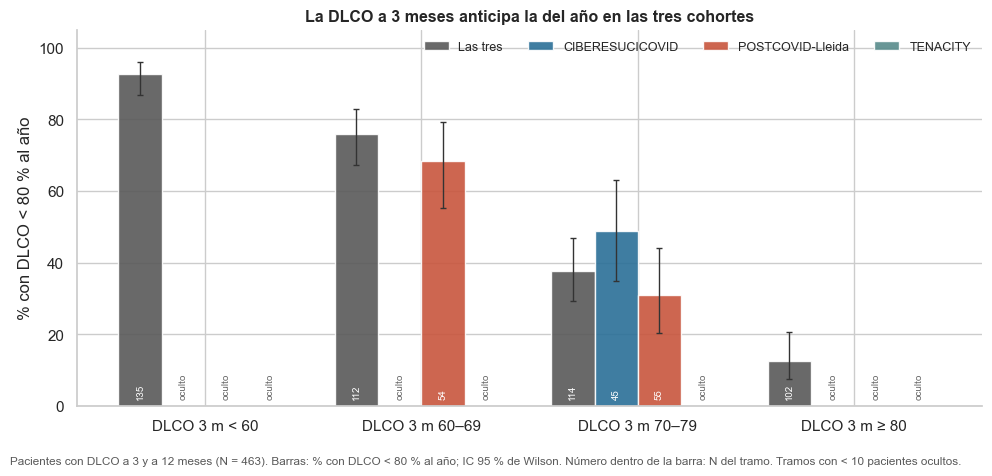

,N,% DLCO < 80 al año,ROC-AUC de la DLCO a 3 m sola,IC95
grupo,,,,
Las tres,463,57.5,0.874,0.84–0.90
CIBERESUCICOVID,197,67.0,0.857,0.79–0.91
POSTCOVID-Lleida,215,56.3,0.874,0.82–0.91
TENACITY,51,25.5,0.919,0.83–0.99


In [4]:
ambas = base[base["dlco_T3"].notna() & base["con_12m"]].copy()
bordes = PARAM["bandas_dlco"] + [np.inf]
etq_bandas = [f"< {bordes[1]}"] + [f"{a}–{b - 1}" for a, b in zip(bordes[1:-2], bordes[2:-1])] + [f"≥ {bordes[-2]}"]
ambas["tramo"] = pd.cut(ambas["dlco_T3"], bordes, right=False, labels=etq_bandas)

filas = []
for grupo, g in [("Las tres", ambas), *[(ETQ[c], ambas[ambas["cohorte"] == c]) for c in COHORTES]]:
    for tramo, t in g.groupby("tramo", observed=False):
        n, k = len(t), int(t["persiste"].sum())
        lo, hi = ic_wilson(k, n)
        visible = n >= N_MIN and not (0 < k < N_MIN or 0 < n - k < N_MIN)
        filas.append({"grupo": grupo, "tramo DLCO 3 m": tramo, "N": n,
                      "% DLCO < 80 al año": round(100 * k / n, 1) if visible else np.nan,
                      "IC95 inf": round(lo, 1) if visible else np.nan, "IC95 sup": round(hi, 1) if visible else np.nan})
tramos = pd.DataFrame(filas)
tramos.to_csv(TAB / f"{PFX}_tramos_todos.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.6))
grupos = ["Las tres", *[ETQ[c] for c in COHORTES]]
colores = {"Las tres": "0.35", **{ETQ[c]: COLOR[c] for c in COHORTES}}
ancho = 0.8 / len(grupos)
for i, gr in enumerate(grupos):
    t = tramos[tramos["grupo"] == gr].reset_index(drop=True)
    x = np.arange(len(etq_bandas)) + (i - (len(grupos) - 1) / 2) * ancho
    v = t["% DLCO < 80 al año"].to_numpy(float)
    ax.bar(x, np.nan_to_num(v), ancho, color=colores[gr], label=gr, alpha=0.9)
    ok = ~np.isnan(v)
    ax.errorbar(x[ok], v[ok], yerr=[v[ok] - t.loc[ok, "IC95 inf"], t.loc[ok, "IC95 sup"] - v[ok]],
                fmt="none", ecolor="0.2", capsize=2.5, lw=1)
    for xi, n, vi in zip(x, t["N"], v):
        visible = not np.isnan(vi)
        ax.text(xi, 2, f"{n}" if visible else "oculto", ha="center", va="bottom", fontsize=7,
                color="white" if visible else "0.4", rotation=90)
ax.set_xticks(range(len(etq_bandas)), [f"DLCO 3 m {e}" for e in etq_bandas])
ax.set_ylabel("% con DLCO < 80 % al año"); ax.set_ylim(0, 105)
ax.set_title("La DLCO a 3 meses anticipa la del año en las tres cohortes")
ax.legend(frameon=False, fontsize=9, ncol=4, loc="upper right")
nota(fig, f"Pacientes con DLCO a 3 y a 12 meses (N = {len(ambas)}). Barras: % con DLCO < 80 % al año; IC 95 % de Wilson. "
          "Número dentro de la barra: N del tramo. Tramos con < 10 pacientes ocultos.")
plt.tight_layout(); guardar(fig, "tramos_todos"); plt.show()

filas = []
for grupo, g in [("Las tres", ambas), *[(ETQ[c], ambas[ambas["cohorte"] == c]) for c in COHORTES]]:
    yy, ss = g["persiste"].to_numpy(int), -g["dlco_T3"].to_numpy()
    lo, hi = ic_bootstrap(yy, ss, roc_auc_score)
    filas.append({"grupo": grupo, "N": len(g), "% DLCO < 80 al año": round(100 * yy.mean(), 1),
                  "ROC-AUC de la DLCO a 3 m sola": round(roc_auc_score(yy, ss), 3), "IC95": f"{lo:.2f}–{hi:.2f}"})
auc_todos = pd.DataFrame(filas).set_index("grupo")
auc_todos.to_csv(TAB / f"{PFX}_auc_dlco_todos.csv")
auc_todos

**Lectura.** Que la DLCO a 3 meses prediga la DLCO al año es casi una tautología: es la misma prueba repetida. Lo que la tabla deja claro es que **la decisión real está entre los alterados**: un paciente con DLCO ≥ 80 % a 3 meses rara vez está alterado al año, mientras que entre los alterados una parte importante se recupera. Por eso el modelo se ajusta **solo en los alterados a 3 meses**: ahí la pregunta no es trivial y cambia la conducta.

## 3 · Modelos y validación dejando fuera cada cohorte

| Modelo | Variables | Por qué |
|---|---|---|
| DLCO a 3 m sola | DLCO | Referencia obligatoria: lo que el clínico ya mira |
| Función a 3 m | DLCO, FVC, FEV1 | ¿Aporta la espirometría a la difusión? |
| Árbol (prof. ≤ 3) | Función + días + alta | Regla de consulta en forma de preguntas sí/no |
| Función + alta (L1) | Función + días + alta | Logística con selección automática de variables (L1); la regularización se elige con validación cruzada **dentro** de las cohortes de entrenamiento |

- **Imputación:** mediana de las cohortes de entrenamiento (solo afecta a los predictores del alta; la función a 3 meses está completa).
- **Ingreso en UCI no se usa:** en CIBERESUCICOVID y TENACITY es ~100 %, así que actúa como indicador de cohorte (notebook 06), no como predictor clínico.
- Cada paciente recibe la predicción de un modelo **que no vio su cohorte**. El AUC "agrupado" junta esas predicciones.

In [5]:
def logistica(cols: list[str], l1: bool = False) -> Pipeline:
    """Imputación por mediana + estandarización + logística (L2 por defecto; L1 con C por validación cruzada)."""
    if l1:
        lr = LogisticRegressionCV(Cs=PARAM["l1_Cs"], penalty="l1", solver="liblinear", scoring="neg_log_loss",
                                  cv=StratifiedKFold(PARAM["pliegues_internos"], shuffle=True, random_state=SEMILLA),
                                  max_iter=5000)
    else:
        lr = LogisticRegression(max_iter=5000)
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler()), ("lr", lr)])


def arbol() -> Pipeline:
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("arbol", DecisionTreeClassifier(max_depth=PARAM["arbol_profundidad"],
                                                      min_samples_leaf=PARAM["arbol_min_hoja"], random_state=SEMILLA))])


COMPLETO = FUN + TIEMPO + ALTA
MODELOS = {                                   # en orden de complejidad (el contrato elige el más sencillo)
    "DLCO a 3 m sola": (logistica(["dlco_T3"]), ["dlco_T3"]),
    "Función a 3 m": (logistica(FUN), FUN),
    "Árbol (prof. ≤ 3)": (arbol(), COMPLETO),
    "Función + alta (L1)": (logistica(COMPLETO, l1=True), COMPLETO),
}
REF = "DLCO a 3 m sola"


def predecir_loco(datos: pd.DataFrame, yv: np.ndarray) -> pd.DataFrame:
    """Probabilidad de persistencia de cada paciente con modelos entrenados SIN su cohorte."""
    pred = pd.DataFrame(np.nan, index=datos.index, columns=list(MODELOS))
    for c in COHORTES:
        fuera = (datos["cohorte"] == c).to_numpy()
        for nombre, (est, cols) in MODELOS.items():
            m = clone(est).fit(datos.loc[~fuera, cols], yv[~fuera])
            pred.loc[fuera, nombre] = m.predict_proba(datos.loc[fuera, cols])[:, 1]
    return pred


def pendiente_calibracion(yv: np.ndarray, p: np.ndarray) -> float:
    """Pendiente de calibración (1 = ideal; < 1 = predicciones demasiado extremas)."""
    q = np.clip(p, 1e-6, 1 - 1e-6)
    try:
        return float(sm.Logit(yv, sm.add_constant(np.log(q / (1 - q)))).fit(disp=0).params[1])
    except Exception:
        return np.nan


P = predecir_loco(A, y)
GRUPOS = {"Agrupado": np.ones(len(A), bool), **{ETQ[c]: (A["cohorte"] == c).to_numpy() for c in COHORTES}}
filas = []
for grupo, m in GRUPOS.items():
    for nombre in MODELOS:
        yy, pp = y[m], P[nombre].to_numpy()[m]
        lo, hi = ic_bootstrap(yy, pp, roc_auc_score)
        filas.append({"evaluada en": grupo, "modelo": nombre, "N": int(m.sum()), "% persiste": round(100 * yy.mean(), 1),
                      "ROC-AUC": round(roc_auc_score(yy, pp), 3), "IC95": f"{lo:.2f}–{hi:.2f}", "auc_lo": lo, "auc_hi": hi,
                      "PR-AUC": round(average_precision_score(yy, pp), 3), "Brier": round(brier_score_loss(yy, pp), 3),
                      "Observado − predicho (pp)": round(100 * (yy.mean() - pp.mean()), 1),
                      "Pendiente de calibración": round(pendiente_calibracion(yy, pp), 2)})
metricas = pd.DataFrame(filas).set_index(["evaluada en", "modelo"])
metricas.drop(columns=["auc_lo", "auc_hi"]).to_csv(TAB / f"{PFX}_metricas_loco.csv")
metricas.drop(columns=["auc_lo", "auc_hi"])

N  % persiste  ROC-AUC       IC95  PR-AUC  Brier  Observado − predicho (pp)  Pendiente de calibración
evaluada en      modelo                                                                                                                      
Agrupado         DLCO a 3 m sola      361        70.1    0.792  0.74–0.84   0.904  0.166                        0.0                      0.87
                 Función a 3 m        361        70.1    0.794  0.75–0.84   0.906  0.165                        0.3                      0.88
                 Árbol (prof. ≤ 3)    361        70.1    0.762  0.71–0.81   0.876  0.188                       -1.2                      0.41
                 Función + alta (L1)  361        70.1    0.775  0.72–0.82   0.899  0.172                        2.3                      0.92
CIBERESUCICOVID  DLCO a 3 m sola      161        77.6    0.793  0.71–0.88   0.921  0.161                       12.0                      0.83
                 Función a 3 m        161        77.6    0.796  0.71–0.88   0.924  0.161                       12.3                      0.82
                 Árbol (prof. ≤ 3)    161        77.6    0.758  0.66–0.85   0.888  0.185                       13.2                      0.47
                 Función + alta (L1)  161        77.6    0.808  0.72–0.89   0.927  0.169                       16.7                      1.06
POSTCOVID-Lleida DLCO a 3 m sola      176        65.9    0.843  0.78–0.90   0.917  0.170                       -9.8                      1.25
                 Función a 3 m        176        65.9    0.842  0.78–0.90   0.919  0.166                       -8.6                      1.26
                 Árbol (prof. ≤ 3)    176        65.9    0.824  0.76–0.88   0.878  0.192                      -12.9                      0.44
                 Función + alta (L1)  176        65.9    0.847  0.79–0.90   0.922  0.172                       -9.3                      1.60
TENACITY         DLCO a 3 m sola       24        50.0    0.830  0.65–0.98   0.863  0.182                       -8.5                      1.37
                 Función a 3 m         24        50.0    0.875  0.72–1.00   0.885  0.181                      -15.0                      1.64
                 Árbol (prof. ≤ 3)     24        50.0    0.809  0.61–0.95   0.810  0.186                      -11.5                      1.06
                 Función + alta (L1)   24        50.0    0.826  0.63–0.98   0.869  0.190                       -9.0                      1.32

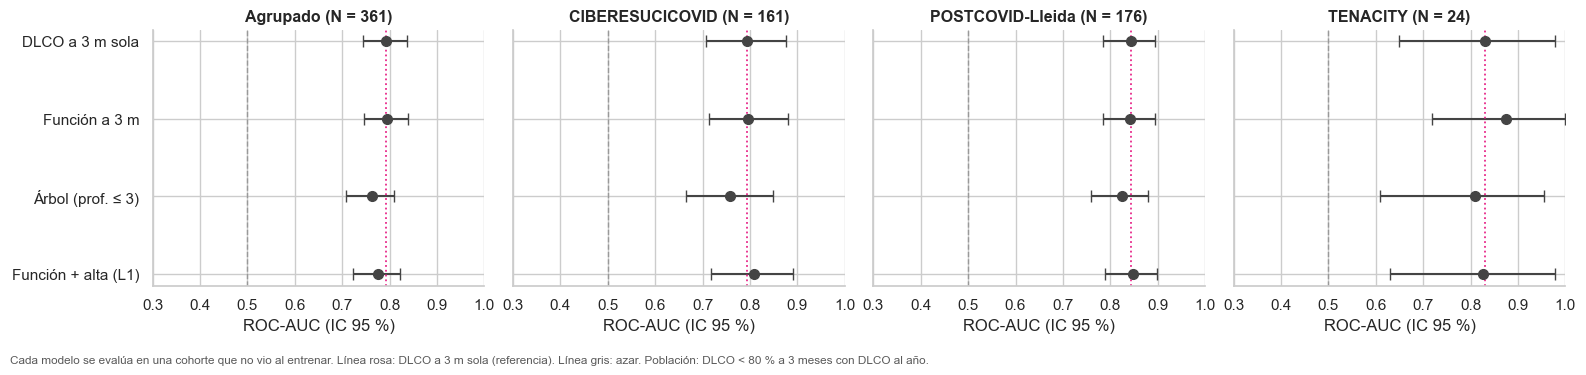

Modelos que mejoran a la referencia (IC del ΔAUC agrupado > 0): ninguno
Modelo final según el contrato: DLCO a 3 m sola


ΔAUC  IC95 inferior  IC95 superior      p
evaluada en      comparación                                                                      
Agrupado         Función a 3 m − DLCO a 3 m sola        0.003         -0.006          0.011  0.582
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.030         -0.059          0.002  0.064
                 Función + alta (L1) − DLCO a 3 m sola -0.016         -0.034         -0.002  0.030
CIBERESUCICOVID  Función a 3 m − DLCO a 3 m sola        0.003         -0.008          0.014  0.562
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.035         -0.075          0.003  0.090
                 Función + alta (L1) − DLCO a 3 m sola  0.016         -0.013          0.043  0.236
POSTCOVID-Lleida Función a 3 m − DLCO a 3 m sola       -0.001         -0.011          0.008  0.820
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.019         -0.064          0.022  0.368
                 Función + alta (L1) − DLCO a 3 m sola  0.004         -0.009          0.018  0.554
TENACITY         Función a 3 m − DLCO a 3 m sola        0.045         -0.022          0.140  0.290
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.021         -0.164          0.132  0.766
                 Función + alta (L1) − DLCO a 3 m sola -0.003         -0.063          0.049  0.910

In [6]:
fig, axes = plt.subplots(1, len(GRUPOS), figsize=(16, 3.6), sharey=True)
nombres = list(MODELOS)[::-1]
for ax, grupo in zip(axes, GRUPOS):
    t = metricas.loc[grupo].loc[nombres]
    ax.errorbar(t["ROC-AUC"], range(len(t)), xerr=[t["ROC-AUC"] - t["auc_lo"], t["auc_hi"] - t["ROC-AUC"]],
                fmt="o", ms=7, capsize=4, color="#444")
    ax.axvline(t.loc[REF, "ROC-AUC"], color="#e7298a", ls=":", lw=1.3)
    ax.axvline(0.5, color="0.6", ls="--", lw=1)
    ax.set_xlim(0.3, 1.0); ax.set_title(f"{grupo} (N = {int(t['N'].iloc[0])})"); ax.set_xlabel("ROC-AUC (IC 95 %)")
axes[0].set_yticks(range(len(nombres)), nombres)
nota(fig, "Cada modelo se evalúa en una cohorte que no vio al entrenar. Línea rosa: DLCO a 3 m sola (referencia). "
          "Línea gris: azar. Población: DLCO < 80 % a 3 meses con DLCO al año.")
plt.tight_layout(); guardar(fig, "auc_loco"); plt.show()

filas = []
for grupo, m in GRUPOS.items():
    for nombre in list(MODELOS)[1:]:
        d, ic, pv = dif_auc(y[m], P[nombre].to_numpy()[m], P[REF].to_numpy()[m])
        filas.append({"evaluada en": grupo, "comparación": f"{nombre} − {REF}", "ΔAUC": round(d, 3),
                      "IC95 inferior": round(ic[0], 3), "IC95 superior": round(ic[1], 3), "p": round(pv, 3)})
delta = pd.DataFrame(filas).set_index(["evaluada en", "comparación"])
delta.to_csv(TAB / f"{PFX}_delta_auc.csv")

# Contrato: el más sencillo que mejore a la referencia en el AUC agrupado con IC que excluya 0
mejoran = [n for n in list(MODELOS)[1:] if delta.loc[("Agrupado", f"{n} − {REF}"), "IC95 inferior"] > 0]
MODELO_FINAL = mejoran[0] if mejoran else REF
print(f"Modelos que mejoran a la referencia (IC del ΔAUC agrupado > 0): {mejoran or 'ninguno'}")
print(f"Modelo final según el contrato: {MODELO_FINAL}")
delta

## 4 · Calibración y utilidad clínica

- **Calibración:** ¿las probabilidades significan lo que dicen? Si el modelo predice un 70 %, ¿persisten 7 de cada 10?
- **Curva de decisión (beneficio neto):** supongamos que se indica seguimiento estrecho o rehabilitación cuando la probabilidad de persistencia supera un umbral. El beneficio neto compara cada modelo con las dos estrategias sin modelo: **seguir a todos** los alterados (lo habitual) y **no seguir a ninguno**. Un modelo solo es útil en los umbrales en los que supera a ambas.

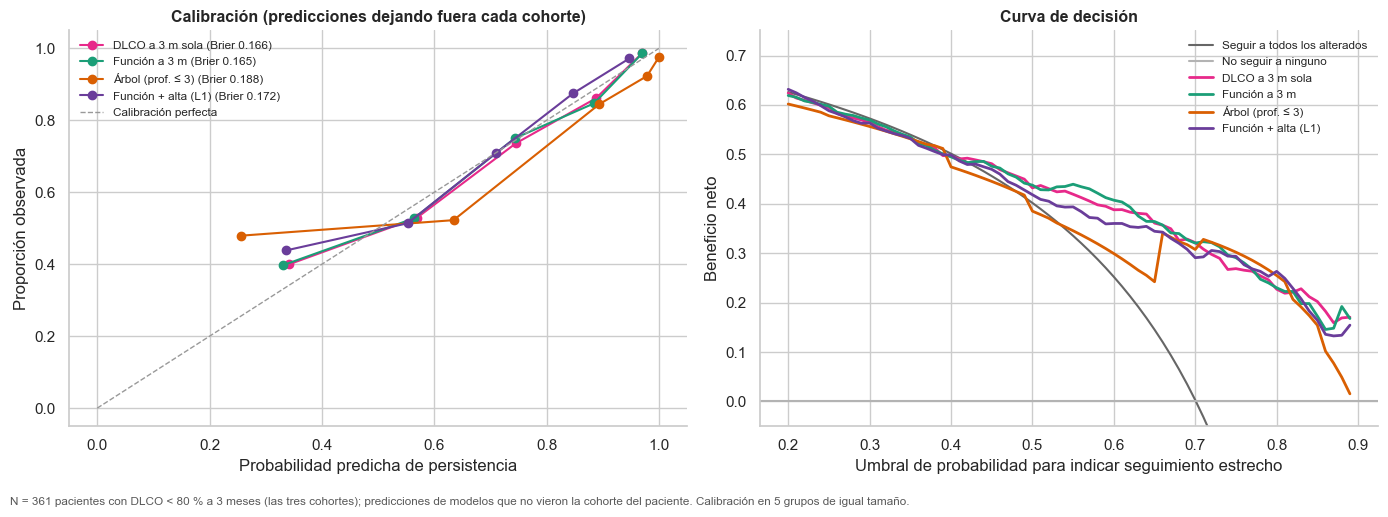

,umbrales con ventaja > 0.01,ventaja máxima (pacientes bien clasificados netos por 100),en el umbral
DLCO a 3 m sola,0.43–0.89,31.9,0.7
Función a 3 m,0.43–0.89,32.3,0.71
Árbol (prof. ≤ 3),0.55–0.89,32.8,0.71
Función + alta (L1),0.45–0.89,30.6,0.72


In [7]:
def beneficio_neto(yv: np.ndarray, p: np.ndarray, umbrales: np.ndarray) -> np.ndarray:
    n = len(yv)
    return np.array([((p >= t) & (yv == 1)).sum() / n - ((p >= t) & (yv == 0)).sum() / n * t / (1 - t) for t in umbrales])


colores_mod = dict(zip(MODELOS, ["#e7298a", "#1b9e77", "#d95f02", "#6a3d9a"]))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for nombre in MODELOS:
    fr, mp = calibration_curve(y, P[nombre], n_bins=PARAM["n_bins_calibracion"], strategy="quantile")
    ax.plot(mp, fr, "o-", color=colores_mod[nombre], label=f"{nombre} (Brier {brier_score_loss(y, P[nombre]):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1, label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha de persistencia"); ax.set_ylabel("Proporción observada")
ax.set_title("Calibración (predicciones dejando fuera cada cohorte)"); ax.legend(frameon=False, fontsize=8.5)

ax = axes[1]
umb = np.arange(*PARAM["umbrales_dca"])
prev = y.mean()
ax.plot(umb, prev - (1 - prev) * umb / (1 - umb), color="0.4", lw=1.5, label="Seguir a todos los alterados")
ax.axhline(0, color="0.7", lw=1.5, label="No seguir a ninguno")
for nombre in MODELOS:
    ax.plot(umb, beneficio_neto(y, P[nombre].to_numpy(), umb), color=colores_mod[nombre], lw=2, label=nombre)
ax.set_ylim(-0.05, prev + 0.05); ax.set_xlabel("Umbral de probabilidad para indicar seguimiento estrecho")
ax.set_ylabel("Beneficio neto"); ax.set_title("Curva de decisión"); ax.legend(frameon=False, fontsize=8.5)
nota(fig, f"N = {len(A)} pacientes con DLCO < 80 % a 3 meses (las tres cohortes); predicciones de modelos que no vieron "
          f"la cohorte del paciente. Calibración en {PARAM['n_bins_calibracion']} grupos de igual tamaño.")
plt.tight_layout(); guardar(fig, "calibracion_decision"); plt.show()

dca = pd.DataFrame({n: beneficio_neto(y, P[n].to_numpy(), umb) for n in MODELOS}, index=np.round(umb, 2))
dca["Seguir a todos"] = prev - (1 - prev) * umb / (1 - umb)
mejor_ref = np.maximum(dca["Seguir a todos"], 0)
filas = {}
for n in MODELOS:
    ventaja = dca[n] - mejor_ref
    util = dca.index[ventaja > PARAM["dca_margen_minimo"]]
    filas[n] = {f"umbrales con ventaja > {PARAM['dca_margen_minimo']}": f"{util.min():.2f}–{util.max():.2f}" if len(util) else "ninguno",
                "ventaja máxima (pacientes bien clasificados netos por 100)": round(100 * ventaja.max(), 1),
                "en el umbral": ventaja.idxmax()}
dca_resumen = pd.DataFrame(filas).T
dca_resumen.to_csv(TAB / f"{PFX}_decision.csv")
dca_resumen

## 5 · Qué aprenden los modelos

Se reajustan con **las tres cohortes juntas** (es el modelo que se usaría) para leer sus coeficientes y reglas. Las métricas válidas siguen siendo las de §3.

Logística L1 (C = 0.234): 6 de 14 variables seleccionadas


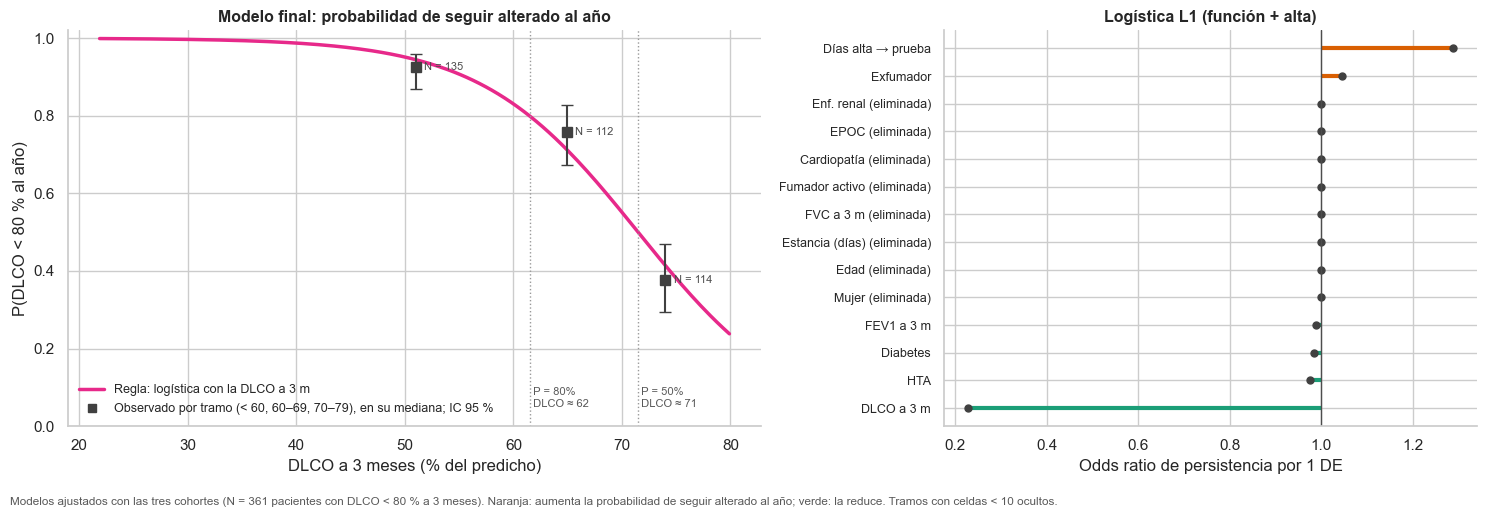

Regla de la DLCO: P(persistencia) = 80 % con DLCO a 3 m ≈ 62 %; P = 50 % con DLCO ≈ 71 %
Función a 3 m (logística): OR de persistencia por 1 DE → DLCO a 3 m 0.20 (1 DE = 11.4 puntos), FVC a 3 m 1.58 (1 DE = 15.5 puntos), FEV1 a 3 m 0.64 (1 DE = 17.3 puntos)


,OR por 1 DE,1 DE equivale a,seleccionada
DLCO a 3 m,0.23,11.4,sí
Días alta → prueba,1.29,23.8,sí
Exfumador,1.05,0.5,sí
HTA,0.98,0.5,sí
Diabetes,0.98,0.4,sí
FEV1 a 3 m,0.99,17.3,sí
Mujer,1.00,0.4,no (L1 la elimina)
Edad,1.00,10.8,no (L1 la elimina)
FVC a 3 m,1.00,15.5,no (L1 la elimina)
Estancia (días),1.00,21.4,no (L1 la elimina)


,N,persisten,se recuperan
regla,,,
DLCO a 3 m ≤ 69 y DLCO a 3 m ≤ 55 y FEV1 a 3 m ≤ 88,74,74/74 (100.0 %),0/74 (0.0 %)
DLCO a 3 m ≤ 69 y DLCO a 3 m ≤ 55 y FEV1 a 3 m > 88,21,19/21 (90.5 %),<10/21
DLCO a 3 m ≤ 69 y DLCO a 3 m > 55 y Días alta → prueba ≤ 96,82,56/82 (68.3 %),26/82 (31.7 %)
DLCO a 3 m ≤ 69 y DLCO a 3 m > 55 y Días alta → prueba > 96,69,61/69 (88.4 %),<10/69
DLCO a 3 m > 69 y Días alta → prueba ≤ 104 y FEV1 a 3 m ≤ 86,23,11/23 (47.8 %),12/23 (52.2 %)
DLCO a 3 m > 69 y Días alta → prueba ≤ 104 y FEV1 a 3 m > 86,35,<10/35,30/35 (85.7 %)
DLCO a 3 m > 69 y Días alta → prueba > 104 y FVC a 3 m ≤ 87,35,13/35 (37.1 %),22/35 (62.9 %)
DLCO a 3 m > 69 y Días alta → prueba > 104 y FVC a 3 m > 87,22,14/22 (63.6 %),<10/22


In [8]:
finales = {n: clone(est).fit(A[cols], y) for n, (est, cols) in MODELOS.items()}

lr_l1 = finales["Función + alta (L1)"].named_steps["lr"]
coef = pd.Series(lr_l1.coef_[0], index=[NOMBRES[c] for c in COMPLETO])
de = A[COMPLETO].std().set_axis(coef.index)
tabla_coef = pd.DataFrame({"OR por 1 DE": np.exp(coef).round(2), "1 DE equivale a": de.round(1),
                           "seleccionada": np.where(coef != 0, "sí", "no (L1 la elimina)")})
tabla_coef = tabla_coef.loc[coef.abs().sort_values(ascending=False).index]
tabla_coef.to_csv(TAB / f"{PFX}_coeficientes_l1.csv")
print(f"Logística L1 (C = {lr_l1.C_[0]:.3g}): {int((coef != 0).sum())} de {len(coef)} variables seleccionadas")

lr_fun = finales["Función a 3 m"].named_steps["lr"]
coef_fun = pd.Series(lr_fun.coef_[0], index=[NOMBRES[c] for c in FUN])
de_fun = A[FUN].std().set_axis(coef_fun.index)

# Curva de la regla: P(persistencia) según la DLCO a 3 m, con lo observado por tramos
regla = finales[REF]
rejilla = pd.DataFrame({"dlco_T3": np.linspace(A["dlco_T3"].min(), U_DLCO - 0.1, 200)})
p_rejilla = regla.predict_proba(rejilla)[:, 1]
cortes = {q: float(rejilla["dlco_T3"][np.argmin(np.abs(p_rejilla - q))]) for q in [0.8, 0.5]}
tramos_A = pd.cut(A["dlco_T3"], PARAM["bandas_dlco"], right=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
ax.plot(rejilla["dlco_T3"], p_rejilla, color="#e7298a", lw=2.5, label="Regla: logística con la DLCO a 3 m")
for intervalo, t in A.groupby(tramos_A, observed=True):
    n, k = len(t), int(t["persiste"].sum())
    if n >= N_MIN and not (0 < k < N_MIN or 0 < n - k < N_MIN):
        lo, hi = ic_wilson(k, n)
        xm = t["dlco_T3"].median()                       # punto en la mediana real del tramo
        ax.errorbar(xm, k / n, yerr=[[k / n - lo / 100], [hi / 100 - k / n]], fmt="s", color="0.25", ms=7, capsize=4)
        ax.text(xm + 0.8, k / n, f"N = {n}", fontsize=8, color="0.3", va="center")
ax.plot([], [], "s", color="0.25", label="Observado por tramo (< 60, 60–69, 70–79), en su mediana; IC 95 %")
for q, x in cortes.items():
    ax.axvline(x, color="0.6", ls=":", lw=1)
    ax.text(x, 0.05, f" P = {q:.0%}\n DLCO ≈ {x:.0f}", fontsize=8, color="0.35")
ax.set_xlabel("DLCO a 3 meses (% del predicho)"); ax.set_ylabel("P(DLCO < 80 % al año)"); ax.set_ylim(0, 1.02)
ax.set_title("Modelo final: probabilidad de seguir alterado al año"); ax.legend(frameon=False, fontsize=9, loc="lower left")

ax = axes[1]
orden = coef.sort_values().index
orx = np.exp(coef[orden])
ax.hlines(range(len(orden)), 1, orx, color=np.where(orx > 1, "#d95f02", np.where(orx < 1, "#1b9e77", "0.7")), lw=3)
ax.plot(orx, range(len(orden)), "o", color="0.25", ms=5)
ax.axvline(1, color="0.3", lw=1)
ax.set_yticks(range(len(orden)), [f"{v}{'' if coef[v] != 0 else ' (eliminada)'}" for v in orden], fontsize=9)
ax.set_xlabel("Odds ratio de persistencia por 1 DE"); ax.set_title("Logística L1 (función + alta)")
nota(fig, f"Modelos ajustados con las tres cohortes (N = {len(A)} pacientes con DLCO < 80 % a 3 meses). "
          "Naranja: aumenta la probabilidad de seguir alterado al año; verde: la reduce. Tramos con celdas < 10 ocultos.")
plt.tight_layout(); guardar(fig, "interpretacion"); plt.show()
print("Regla de la DLCO: P(persistencia) = 80 % con DLCO a 3 m ≈ {:.0f} %; P = 50 % con DLCO ≈ {:.0f} %".format(cortes[0.8], cortes[0.5]))
print("Función a 3 m (logística): OR de persistencia por 1 DE →",
      ", ".join(f"{k} {np.exp(v):.2f} (1 DE = {de_fun[k]:.1f} puntos)" for k, v in coef_fun.items()))
display(tabla_coef)

# Árbol como tabla de reglas (los recuentos pequeños de las hojas se suprimen)
arb = finales["Árbol (prof. ≤ 3)"].named_steps["arbol"]
hojas = arb.apply(finales["Árbol (prof. ≤ 3)"].named_steps["imp"].transform(A[COMPLETO]))
t_ = arb.tree_
padres = {h: (n, "≤") for n in range(t_.node_count) for h in [t_.children_left[n]] if h != -1}
padres |= {h: (n, ">") for n in range(t_.node_count) for h in [t_.children_right[n]] if h != -1}
filas = []
for hoja in np.unique(hojas):
    camino, nodo = [], hoja
    while nodo in padres:
        n, signo = padres[nodo]
        camino.append(f"{NOMBRES[COMPLETO[t_.feature[n]]]} {signo} {t_.threshold[n]:.0f}")
        nodo = n
    m = hojas == hoja
    filas.append({"regla": " y ".join(reversed(camino)), "N": int(m.sum()),
                  "persisten": privacidad.proporcion_segura(int(y[m].sum()), int(m.sum()), N_MIN),
                  "se recuperan": privacidad.proporcion_segura(int((1 - y[m]).sum()), int(m.sum()), N_MIN)})
reglas_arbol = pd.DataFrame(filas).set_index("regla")
reglas_arbol.to_csv(TAB / f"{PFX}_reglas_arbol.csv")
reglas_arbol

## 6 · Sensibilidad

1. **Pérdidas antes de la visita anual (IPW).** Se modela la probabilidad de tener DLCO al año entre **todos** los alterados a 3 meses (función a 3 meses, edad, estancia y cohorte) y se pondera a cada paciente observado por la inversa de esa probabilidad. Si el resultado cambia poco, la selección no explica las conclusiones.
2. **Ventana anual estricta.** Solo visitas anuales entre 10 y 14 meses (300–420 días), para descartar que el resultado dependa de medir "el año" demasiado pronto o demasiado tarde.

In [9]:
VARS_SEG = FUN + ["edad", "estancia_hosp_dias"]
alt = base[base["alterada_3m"]].copy()
X_seg = pd.concat([alt[VARS_SEG], pd.get_dummies(alt["cohorte"], drop_first=True, dtype=float)], axis=1)
m_seg = Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler()),
                  ("lr", LogisticRegression(max_iter=5000))]).fit(X_seg, alt["con_12m"].astype(int))
p_obs = pd.Series(m_seg.predict_proba(X_seg)[:, 1], index=alt.index)
peso = (alt["con_12m"].mean() / p_obs).loc[A.index].to_numpy()          # pesos estabilizados
print(f"Pesos IPW: mediana {np.median(peso):.2f}, rango {peso.min():.2f}–{peso.max():.2f}; "
      f"AUC del modelo de seguimiento: {roc_auc_score(alt['con_12m'], p_obs):.2f} (cerca de 0,5 = seguimiento poco selectivo)")

A["tramo"] = pd.cut(A["dlco_T3"], PARAM["bandas_dlco"], right=False,
                    labels=[f"< {PARAM['bandas_dlco'][1]}"] + [f"{a}–{b - 1}" for a, b in
                                                               zip(PARAM["bandas_dlco"][1:-1], PARAM["bandas_dlco"][2:])])
filas = []
for tramo, t in A.groupby("tramo", observed=False):
    m = (A["tramo"] == tramo).to_numpy()
    filas.append({"tramo DLCO 3 m": tramo, "N": int(m.sum()), "% persiste (bruto)": round(100 * y[m].mean(), 1),
                  "% persiste (IPW)": round(100 * np.average(y[m], weights=peso[m]), 1)})
filas.append({"tramo DLCO 3 m": "Todos", "N": len(A), "% persiste (bruto)": round(100 * y.mean(), 1),
              "% persiste (IPW)": round(100 * np.average(y, weights=peso), 1)})
display(pd.DataFrame(filas).set_index("tramo DLCO 3 m"))

v0, v1 = PARAM["ventana_anual_estricta"]
estricta = A["dlco_T12_dias"].between(v0, v1).to_numpy()
filas = []
for nombre in MODELOS:
    pp = P[nombre].to_numpy()
    filas.append({"modelo": nombre, "AUC principal": round(roc_auc_score(y, pp), 3),
                  "AUC con IPW": round(roc_auc_score(y, pp, sample_weight=peso), 3),
                  f"AUC ventana {v0}–{v1} d (N = {estricta.sum()})": round(roc_auc_score(y[estricta], pp[estricta]), 3)})
sensibilidad = pd.DataFrame(filas).set_index("modelo")
sensibilidad.to_csv(TAB / f"{PFX}_sensibilidad.csv")
sensibilidad

Pesos IPW: mediana 1.00, rango 0.61–1.88; AUC del modelo de seguimiento: 0.63 (cerca de 0,5 = seguimiento poco selectivo)


,N,% persiste (bruto),% persiste (IPW)
tramo DLCO 3 m,,,
< 60,135,92.6,93.0
60–69,112,75.9,77.3
70–79,114,37.7,40.2
Todos,361,70.1,71.6


,AUC principal,AUC con IPW,AUC ventana 300–420 d (N = 301)
modelo,,,
DLCO a 3 m sola,0.792,0.786,0.786
Función a 3 m,0.794,0.789,0.790
Árbol (prof. ≤ 3),0.762,0.755,0.758
Función + alta (L1),0.775,0.770,0.771


## 7 · Herramienta de bolsillo para la consulta de los 3 meses

Lo que se lleva el clínico: **de los pacientes con DLCO < 80 % a los 3 meses, cuántos se recuperan al año según su DLCO**, en las tres cohortes juntas y en cada una. Después, el modelo final aplicado a tres pacientes **ficticios**.

In [10]:
filas = []
for grupo, g in [("Las tres", A), *[(ETQ[c], A[A["cohorte"] == c]) for c in COHORTES]]:
    for tramo, t in g.groupby("tramo", observed=False):
        n, k = len(t), int((t["persiste"] == 0).sum())
        lo, hi = ic_wilson(k, n)
        visible = n >= N_MIN and not (0 < k < N_MIN or 0 < n - k < N_MIN)
        filas.append({"grupo": grupo, "DLCO a 3 m": tramo, "N": n if n >= N_MIN else np.nan,
                      "% se recupera al año": f"{100 * k / n:.0f} %" if visible else "suprimido (N < 10)",
                      "IC 95 %": f"{lo:.0f}–{hi:.0f} %" if visible else ""})
bolsillo = pd.DataFrame(filas).astype({"N": "Int64"}).set_index(["grupo", "DLCO a 3 m"])
bolsillo.to_csv(TAB / f"{PFX}_tabla_bolsillo.csv")
display(bolsillo)

modelo_final = finales[MODELO_FINAL]
cols_final = MODELOS[MODELO_FINAL][1]
ejemplos = pd.DataFrame([
    {"dlco_T3": 55, "fvc_T3": 70, "fev1_T3": 72, "dlco_T3_dias": 95, "edad": 67, "sexo": 0, "estancia_hosp_dias": 40,
     "nu_hta": 1, "nu_diabetes": 1, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 1},
    {"dlco_T3": 66, "fvc_T3": 85, "fev1_T3": 88, "dlco_T3_dias": 95, "edad": 57, "sexo": 1, "estancia_hosp_dias": 25,
     "nu_hta": 0, "nu_diabetes": 0, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 0},
    {"dlco_T3": 76, "fvc_T3": 95, "fev1_T3": 97, "dlco_T3_dias": 95, "edad": 52, "sexo": 0, "estancia_hosp_dias": 15,
     "nu_hta": 0, "nu_diabetes": 0, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 0},
], index=["A · DLCO 55 %, FVC 70 %", "B · DLCO 66 %, FVC 85 %", "C · DLCO 76 %, FVC 95 %"])
ejemplos["P(sigue alterado al año)"] = modelo_final.predict_proba(ejemplos[cols_final])[:, 1].round(2)
print(f"Modelo final: {MODELO_FINAL}. Pacientes ficticios, no reales:")
ejemplos[["dlco_T3", "fvc_T3", "P(sigue alterado al año)"]]

N % se recupera al año  IC 95 %
grupo            DLCO a 3 m                                    
Las tres         < 60         135                  7 %   4–13 %
                 60–69        112                 24 %  17–33 %
                 70–79        114                 62 %  53–71 %
CIBERESUCICOVID  < 60          63   suprimido (N < 10)         
                 60–69         53   suprimido (N < 10)         
                 70–79         45                 51 %  37–65 %
POSTCOVID-Lleida < 60          67   suprimido (N < 10)         
                 60–69         54                 31 %  21–45 %
                 70–79         55                 69 %  56–80 %
TENACITY         < 60        <NA>   suprimido (N < 10)         
                 60–69       <NA>   suprimido (N < 10)         
                 70–79         14   suprimido (N < 10)

Modelo final: DLCO a 3 m sola. Pacientes ficticios, no reales:


,dlco_T3,fvc_T3,P(sigue alterado al año)
"A · DLCO 55 %, FVC 70 %",55,70,0.91
"B · DLCO 66 %, FVC 85 %",66,85,0.68
"C · DLCO 76 %, FVC 95 %",76,95,0.35


## 8 · Guardar

In [11]:
A.drop(columns=["tramo"]).reset_index().to_parquet(DATOS / "dataset_modelo_primera_visita.parquet", index=False)
with open(DATOS / "modelo_primera_visita.pkl", "wb") as f:
    pickle.dump({"modelo": modelo_final, "nombre": MODELO_FINAL, "predictores": cols_final,
                 "modelos": finales, "columnas": {n: c for n, (_, c) in MODELOS.items()},
                 "diana": f"DLCO < {U_DLCO} % a 12 meses entre los alterados a 3 meses",
                 "tabla_bolsillo": bolsillo, "semilla": SEMILLA}, f)
print(f"Guardados {DATOS.name}/dataset_modelo_primera_visita.parquet y {DATOS.name}/modelo_primera_visita.pkl "
      "(fuera del repositorio)")

Guardados Datos limpios/dataset_modelo_primera_visita.parquet y Datos limpios/modelo_primera_visita.pkl (fuera del repositorio)


## 9 · Resumen

**Resultados (ejecución con semilla 2026; ver §1–§7).**

1. **La visita de los 3 meses ya decide mucho (§2).** En los 463 pacientes con DLCO a 3 y 12 meses, la DLCO a 3 meses sola ordena a quién seguirá alterado al año con un **ROC-AUC de 0,87** [0,84–0,90]: 0,86 en CIBERESUCICOVID, 0,87 en Lleida y 0,92 en TENACITY. Con DLCO ≥ 80 % a 3 meses, solo el 13 % está alterado al año. La decisión real está **entre los alterados**.
2. **Entre los alterados (N = 361; persiste el 70 %), la DLCO sola sigue discriminando bien en cohortes no vistas (§3):**
   - AUC **0,79** [0,74–0,84] agrupado;
   - 0,79 en CIBERESUCICOVID, 0,84 en Lleida y 0,83 en TENACITY (N = 24, IC muy ancho).
3. **Nada mejora a la DLCO sola, y el contrato elige la regla.**
   - Añadir FVC y FEV1: ΔAUC +0,003 [−0,006 a +0,011].
   - Árbol: −0,030 [−0,059 a +0,002].
   - Logística L1 con función + alta: −0,016 [−0,034 a −0,002], es decir, **algo peor**.

   La espirometría, la edad, la estancia y las comorbilidades no aportan nada una vez se conoce la DLCO.
4. **Tabla de bolsillo (§7).** De los pacientes con DLCO < 80 % a 3 meses, se recuperan al año:
   - **DLCO < 60 %: el 7 %** [4–13];
   - **60–69 %: el 24 %** [17–33];
   - **70–79 %: el 62 %** [53–71].

   En la curva de la regla, P(persistencia) = 80 % con una DLCO ≈ 62 % y 50 % con una DLCO ≈ 71 %. El patrón se repite en Lleida (31 % y 69 % en los tramos visibles) y en CIBERESUCICOVID (51 % en 70–79).
5. **La ordenación viaja; el nivel absoluto, no (§3–§4).**
   - La calibración agrupada es buena: observado − predicho = 0 pp y pendiente 0,87.
   - Por cohorte, CIBERESUCICOVID persiste **12 puntos más** de lo predicho y Lleida 10 puntos menos.
   - Consecuencia: **los tramos sirven en cualquier hospital para ordenar a los pacientes**, pero las probabilidades exactas deberían recalibrarse con datos locales.
6. **Utilidad clínica (§4).** Usar el modelo supera a "seguir a todos los alterados" en los umbrales de 0,43 a 0,89. Es decir, sirve si solo se quiere intensificar el seguimiento cuando el riesgo de persistir supera ~45 %. Los cuatro modelos dan prácticamente el mismo beneficio neto.
7. **Qué aprende (§5).**
   - La DLCO a 3 meses domina: OR 0,23 por cada 11 puntos.
   - Lo único más que retiene la L1 con peso apreciable son los **días desde el alta hasta la prueba**: OR 1,29 por cada 24 días. Una DLCO baja medida más tarde deja menos margen de recuperación.
   - La FVC no añade nada, en línea con el resto.
8. **Robusto (§6).**
   - La llegada a la visita anual es poco selectiva: AUC del modelo de seguimiento 0,63 y medianas de DLCO a 3 meses parecidas en quienes vuelven y quienes no.
   - Con IPW, las tasas por tramo cambian < 3 puntos y el AUC queda en 0,79.
   - Con la visita anual entre 10 y 14 meses, el AUC también queda en 0,79.

**Comparación con los modelos anteriores.** Los modelos al alta (notebook 06) se quedaban en AUC ≈ 0,63 para el fenotipo a 3 meses. El EBM de CIBERESUCICOVID con alta + fase aguda + función a 3 meses (notebook 07) llegaba a 0,71 en un test de 95 pacientes. Una sola variable de la visita de los 3 meses, validada en cohortes no vistas, da **0,79 entre los alterados y 0,87 en todos**.

**Mensaje para la consulta**
- **DLCO < 60 % a los 3 meses:** 9 de cada 10 seguirán alterados al año. Son candidatos a seguimiento estrecho y rehabilitación desde ya.
- **DLCO 70–79 %:** la mayoría (6 de cada 10) se recupera. Se puede espaciar el seguimiento con una DLCO de control al año.
- **DLCO 60–69 %:** zona intermedia; 3 de cada 4 siguen alterados.
- **Ni la espirometría ni los datos del alta cambian la decisión** cuando se tiene la DLCO.

**Limitaciones**
- **N modesto:** 361 pacientes, y solo 24 de TENACITY. Los IC por cohorte son anchos.
- **Umbral fijo del 80 %**, no el límite inferior de la normalidad. Parte de la "recuperación" del tramo 70–79 puede ser **variabilidad de la prueba** (regresión a la media cerca del umbral). Una diana alternativa sería una mejora ≥ 10 puntos.
- **Solo entran pacientes con DLCO medida.** En CIBERESUCICOVID, la DLCO depende del centro (notebook 01): el resultado vale para quien se hace la prueba.
- **La calibración no transfiere entre cohortes:** las probabilidades absolutas deben recalibrarse localmente antes de usarlas.